# HW 3

**Sepehr Ilami**

**November 2025**

**Github Link**:
**https://github.com/sepehrilami/phys7332_fa25/blob/main/assignments/assignment03.ipynb**

## Question 1

### a)

In [13]:
import networkx as nx
import numpy as np
from collections import defaultdict
import scipy.sparse as sp
from networkx.algorithms import community
import time
import seaborn as sns
import pandas as pd
import os
import warnings
warnings.filterwarnings("ignore")
import random
import scipy.io
import graph_tool.all as gt
from sklearn.metrics import normalized_mutual_info_score
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, LogLocator
import matplotlib as mpl

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
mpl.rcParams['font.size'] = 11
mpl.rcParams['axes.linewidth'] = 1.2
mpl.rcParams['xtick.major.width'] = 1.2
mpl.rcParams['ytick.major.width'] = 1.2
mpl.rcParams['xtick.minor.width'] = 0.8
mpl.rcParams['ytick.minor.width'] = 0.8


Processing m = 1
Processing m = 2
Processing m = 3
Processing m = 4
Processing m = 5


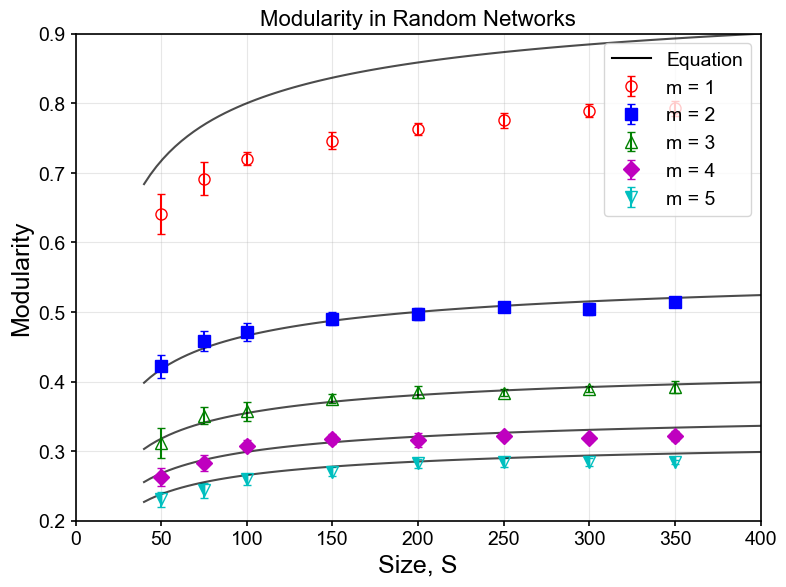

In [14]:


def calculate_modularity(G):
    """Calculate modularity using Louvain community detection"""
    try:
        communities = community.louvain_communities(G, seed=42)
        modularity = community.modularity(G, communities)
        return modularity
    except:
        return 0

def theoretical_curve(S, m, a=0.165):
    """Theoretical prediction following Equation format"""
    return (a + (1 - a)/m)*(1 - (2/np.sqrt(S)))

def generate_random_graph(n, m_param):
    """Generate a random graph with n nodes and edge density based on m"""
    # For random graphs, we interpret m as controlling the edge density
    # Higher m means more edges per node on average
    avg_degree = 2 * m_param  # Average degree
    num_edges = int(n * avg_degree / 2)
    
    # Ensure we don't exceed maximum possible edges
    max_edges = n * (n - 1) // 2
    num_edges = min(num_edges, max_edges)
    
    # Generate random graph
    G = nx.gnm_random_graph(n, num_edges, seed=None)
    
    # Ensure the graph is connected for meaningful modularity
    if not nx.is_connected(G):
        # Add edges to connect components
        components = list(nx.connected_components(G))
        for i in range(len(components) - 1):
            node1 = list(components[i])[0]
            node2 = list(components[i + 1])[0]
            G.add_edge(node1, node2)
    
    return G

m_values = [1, 2, 3, 4, 5]
markers = ['o', 's', '^', 'D', 'v']
sizes = [50, 75, 100, 150, 200, 250, 300, 350]
num_trials = 10  # Number of trials for each configuration
colors = ['r', 'b', 'g', 'm', 'c']
fillstyles = ['none', 'full', 'none', 'full', 'left']

# Store results
results = {m: {'sizes': [], 'modularity_mean': [], 'modularity_std': []} for m in m_values}

# Calculate modularity for each configuration
for m in m_values:
    print(f"Processing m = {m}")
    for size in sizes:
        modularities = []
        for trial in range(num_trials):
            G = generate_random_graph(size, m)
            mod = calculate_modularity(G)
            modularities.append(mod)
        
        results[m]['sizes'].append(size)
        results[m]['modularity_mean'].append(np.mean(modularities))
        results[m]['modularity_std'].append(np.std(modularities))

# Create the plot
plt.figure(figsize=(8, 6))

# Plot data points and theoretical curves
for i, m in enumerate(m_values):
    sizes = np.array(results[m]['sizes'])
    means = np.array(results[m]['modularity_mean'])
    stds = np.array(results[m]['modularity_std'])
    
    # Plot data points with error bars
    plt.errorbar(sizes, means, yerr=stds, 
                marker=markers[i], markersize=8,
                fillstyle=fillstyles[i], color=colors[i],
                linestyle='none', capsize=3,
                label=f'm = {m}')
    
    # Plot theoretical curves
    sizes_theory = np.linspace(40, 400, 100)
    # Adjust the theoretical curve to better match random graph behavior
    modularity_theory = theoretical_curve(sizes_theory, m, a=0.165)
    modularity_theory = modularity_theory
    plt.plot(sizes_theory, modularity_theory, 'k-', linewidth=1.5, alpha=0.7)

# Add the legend entry for Equation
plt.plot([], [], 'k-', linewidth=1.5, label='Equation')

# Formatting
plt.xlabel('Size, S', fontsize=18)
plt.ylabel('Modularity', fontsize=18)
plt.xlim(0, 400)
plt.ylim(0.2, 0.9)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, alpha=0.3)

# Create custom legend
handles, labels = plt.gca().get_legend_handles_labels()
legend_order = [0, 1, 2, 3, 4, 5]  # Order: m=1 to m=5, then Equation
handles = [handles[i] for i in legend_order]
labels = [labels[i] for i in legend_order]
plt.legend(handles, labels, loc='upper right', fontsize=14, frameon=True)

plt.title('Modularity in Random Networks', fontsize=16)

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
plt.show()

For “normal” densities (m≥2), optimized modularity in random graphs follows almost the same scaling as in scale-free networks, emphasizing that high Q can be a purely random effect.

For very sparse random graphs (m=1), the simple ansatz breaks down, highlighting that modularity is also sensitive to sparsity and local structure, not just to “true” communities.

It shows that modularity by itself is a relative and model-dependent measure of partition quality, not an absolute indicator that communities are really present.

### b)

In [25]:
# load dataset of gt.collections.ns["polblogs"]
g = gt.collection.ns["polblogs"]

# get the largest connected component
g = gt.extract_largest_component(g, directed=False)

# use minimize blockmodel dl function to find communities

''' Fit a degree-corrected and non-degree-corrected stochas-
tic block model to the largest connected component of the polblogs dataset, and
enforce that the resulting partitions only contain two blocks. Visualize the graph
(twice) with the two different partitions. '''

state_dc = gt.minimize_blockmodel_dl(g, degree_corr=True)
state_nodc = gt.minimize_blockmodel_dl(g)
gt.graph_draw(g, vertex_fill_color=state_dc.get_blocks(), output_size=(600, 600), output=None)
gt.graph_draw(g, vertex_fill_color=state_nodc.get_blocks(), output_size=(600, 600), output=None)

TypeError: minimize_blockmodel_dl() got an unexpected keyword argument 'degree_corr'

### c)

### d)

## Question 2

### a)

### b)

### c)

## Question 3

### a)

### b)

## Question 4